# 40 - Bootstrap CI Table Generation
## Input Data
- **NetCDF files** with pre-computed bootstrap results (1000 iterations per cell) (Notebook 04)
- Variables: `cell_intensity`, `cell_ci_lower` (2.5th %), `cell_ci_upper` (97.5th %)
- Spatial: 441 grid cells (21×21) per metropolitan domain
- Temporal: 6 return periods (2, 5, 10, 25, 50, 100 years) × 3 durations (15-min, 1-hr, 24-hr)

## Processing Steps

1. **Extract CI width** for each grid cell:
   - `ci_width = upper - lower` (full 95% CI)
   - `ci_half = ci_width / 2` (for ± notation)
   - `relative_unc = (ci_width / intensity) × 100` (as %)

2. **Aggregate across domain**:
   - Take **median** of intensity across 441 cells
   - Take **median** of CI half-width across 441 cells
   - Take **median** of relative uncertainty across 441 cells -- (not shown in suplementry tables, but for comparing across durations, e.g., "..., bootstrap confidence intervals for 24-hour extremes are substantially wider (42--76\% relative uncertainty) than for sub-hourly events (17--27\%)... ")

3. **Format for LaTeX**:
   - Output: `intensity (±ci_half)` format
   - Example: `28.5 (±6.1)` mm/hr

## Output
- **Three tables** (Tables S1-S3) for 15-min, 1-hr, 24-hr durations
- **8 cities × 5 scenarios × 6 return periods**
- **Relative uncertainty** Diagnostic figures to examine uncertainty by duration and scenario relative to historical computed values



In [13]:
# PATH CONFIGURATION - EDIT THIS SECTION

# Set DATA_ROOT to the location where you extracted SDHI_Precip_supporting_data.tar.gz
DATA_ROOT = "/path/to/SDHI_Precip_supporting_data"  # <-- EDIT THIS LINE, if notebook is in root you can use "./"

# Derived paths (no editing needed below this line)
IDF_CURVES_BASE = f"{DATA_ROOT}/idf_curves"

# Output settings (relative paths - no editing needed)
OUTPUT_DIR = f"{DATA_ROOT}./output"  # LaTeX tables and relative uncerntity saved here



In [2]:
import xarray as xr
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Test example - Load Seattle HIST IDF NetCDF 
idf_file = f"{IDF_CURVES_BASE}/HIST/seattle/idf_curves_HIST_1990-2005_seattle_v1.nc"
ds = xr.open_dataset(idf_file)

# Extract data
cell_intensity = ds['cell_intensity'].values  # (lat, lon, return_period, duration)
cell_ci_lower = ds['cell_ci_lower'].values
cell_ci_upper = ds['cell_ci_upper'].values
return_periods = ds['return_period'].values
duration_labels = ds['duration_label'].values

# Calculate bootstrap CI widths for each cell
ci_width = cell_ci_upper - cell_ci_lower

# Calculate relative uncertainty (as % of intensity)
relative_uncertainty = (ci_width / cell_intensity) * 100

# For the median IDF curve (what you report), get statistics
# Reshape to (21*21 (441) cells, return_periods, durations)
lat_size, lon_size = cell_intensity.shape[0], cell_intensity.shape[1]
n_cells = lat_size * lon_size

# Focus on 100-year, 15-min (most extreme case)
rp_idx = list(return_periods).index(100)
dur_idx = list(duration_labels).index('15min')

# Extract for this return period/duration
intensity_100yr_15min = cell_intensity[:, :, rp_idx, dur_idx].flatten()
ci_lower_100yr_15min = cell_ci_lower[:, :, rp_idx, dur_idx].flatten()
ci_upper_100yr_15min = cell_ci_upper[:, :, rp_idx, dur_idx].flatten()

# Filter out NaNs
valid_mask = ~np.isnan(intensity_100yr_15min)
intensity_valid = intensity_100yr_15min[valid_mask]
ci_lower_valid = ci_lower_100yr_15min[valid_mask]
ci_upper_valid = ci_upper_100yr_15min[valid_mask]

# Calculate CI statistics
ci_width_valid = ci_upper_valid - ci_lower_valid
relative_unc_valid = (ci_width_valid / intensity_valid) * 100

# Summary statistics
print("=== BOOTSTRAP CI ANALYSIS: Seattle HIST, 100-year, 15-min ===")
print(f"\nNumber of valid cells: {len(intensity_valid)}")
print(f"\nIntensity (fitted Gumbel quantile):")
print(f"  Median across cells: {np.median(intensity_valid):.2f} mm/hr")
print(f"  10th-90th percentile: {np.percentile(intensity_valid, 10):.2f} - {np.percentile(intensity_valid, 90):.2f} mm/hr")

print(f"\nBootstrap CI width (97.5th - 2.5th percentile):")
print(f"  Median: {np.median(ci_width_valid):.2f} mm/hr")
print(f"  Mean: {np.mean(ci_width_valid):.2f} mm/hr")
print(f"  10th-90th percentile: {np.percentile(ci_width_valid, 10):.2f} - {np.percentile(ci_width_valid, 90):.2f} mm/hr")

print(f"\nRelative uncertainty (CI width / intensity × 100%):")
print(f"  Median: {np.median(relative_unc_valid):.1f}%")
print(f"  Mean: {np.mean(relative_unc_valid):.1f}%")
print(f"  10th-90th percentile: {np.percentile(relative_unc_valid, 10):.1f}% - {np.percentile(relative_unc_valid, 90):.1f}%")

# Now do the same for all durations and return periods
print("\n=== SUMMARY ACROSS ALL DURATIONS AND RETURN PERIODS ===")
for dur_idx, dur_label in enumerate(duration_labels):
    print(f"\n{dur_label}:")
    for rp_idx, rp in enumerate(return_periods):
        intensity_vals = cell_intensity[:, :, rp_idx, dur_idx].flatten()
        ci_lower_vals = cell_ci_lower[:, :, rp_idx, dur_idx].flatten()
        ci_upper_vals = cell_ci_upper[:, :, rp_idx, dur_idx].flatten()
        
        valid = ~np.isnan(intensity_vals)
        if np.sum(valid) > 0:
            ci_width = ci_upper_vals[valid] - ci_lower_vals[valid]
            rel_unc = (ci_width / intensity_vals[valid]) * 100
            
            print(f"  {int(rp)}-year: median CI = ±{np.median(ci_width)/2:.2f} mm/hr ({np.median(rel_unc):.1f}%)")

=== BOOTSTRAP CI ANALYSIS: Seattle HIST, 100-year, 15-min ===

Number of valid cells: 441

Intensity (fitted Gumbel quantile):
  Median across cells: 28.48 mm/hr
  10th-90th percentile: 23.57 - 38.10 mm/hr

Bootstrap CI width (97.5th - 2.5th percentile):
  Median: 12.16 mm/hr
  Mean: 14.14 mm/hr
  10th-90th percentile: 6.90 - 25.53 mm/hr

Relative uncertainty (CI width / intensity × 100%):
  Median: 42.0%
  Mean: 45.6%
  10th-90th percentile: 27.5% - 70.6%

=== SUMMARY ACROSS ALL DURATIONS AND RETURN PERIODS ===

15min:
  2-year: median CI = ±2.07 mm/hr (28.5%)
  5-year: median CI = ±2.87 mm/hr (31.7%)
  10-year: median CI = ±3.61 mm/hr (34.7%)
  25-year: median CI = ±4.61 mm/hr (37.7%)
  50-year: median CI = ±5.35 mm/hr (39.9%)
  100-year: median CI = ±6.08 mm/hr (42.0%)

30min:
  2-year: median CI = ±1.70 mm/hr (28.9%)
  5-year: median CI = ±2.37 mm/hr (31.5%)
  10-year: median CI = ±2.92 mm/hr (33.8%)
  25-year: median CI = ±3.69 mm/hr (37.3%)
  50-year: median CI = ±4.27 mm/hr (39.

In [3]:
# Analysis Configuration

# Define cities (in order for tables)
CITIES = [
    ('Albany, NY', 'albany'),
    ('Amarillo, TX', 'amarillo'),
    ('Grand Junction, CO', 'grand_junction'),
    ('Minneapolis, MN', 'minneapolis'),
    ('Nashville, TN', 'nashville'),
    ('Phoenix, AZ', 'phoenix'),
    ('Seattle, WA', 'seattle'),
    ('Tallahassee, FL', 'tallahassee')
]

# Define scenarios (row order in tables)
SCENARIOS = [
    ('HIST', 'HIST', '1990-2005'),
    ('MID (RCP4.5)', 'MID4p5', '2040-2055'),
    ('MID (RCP8.5)', 'MID8p5', '2040-2055'),
    ('EOC (RCP4.5)', 'EOC4p5', '2085-2100'),
    ('EOC (RCP8.5)', 'EOC8p5', '2085-2100')
]

# Durations to extract (in hours)
DURATIONS = {
    '15min': 0.25,
    '1hr': 1.0,
    '24hr': 24.0
}

# Duration labels for tables
duration_labels = {
    '15min': '15-minute',
    '1hr': '1-hour',
    '24hr': '24-hour'
}

# Return periods
RETURN_PERIODS = [2, 5, 10, 25, 50, 100]

In [4]:
def load_idf_data(scenario_dir, city_dir, years):
    """Load IDF curve data for a specific city and scenario"""
    file_path = os.path.join(
        IDF_CURVES_BASE,  # <-- Uses configured path
        scenario_dir, 
        city_dir, 
        f"idf_curves_{scenario_dir}_{years}_{city_dir}_v1.nc"
    )
    
    if os.path.exists(file_path):
        return xr.open_dataset(file_path, engine='netcdf4')
    else:
        print(f"Warning: File not found: {file_path}")
        return None

In [5]:
def extract_duration_data(ds, duration_hours):
    """Extract data for a specific duration from the dataset"""
    if ds is None:
        return None
    
    # Find the duration index
    duration_idx = np.where(ds.duration.values == duration_hours)[0]
    
    if len(duration_idx) == 0:
        print(f"Warning: Duration {duration_hours} not found")
        return None
    
    duration_idx = duration_idx[0]
    
    # Extract the "ensemble" statistics (total abuse of the term, but it is what I used at the time)
    data = {
        'lower': ds.ensemble_lower[:, duration_idx].values,
        'median': ds.ensemble_median[:, duration_idx].values,
        'upper': ds.ensemble_upper[:, duration_idx].values,
        'return_periods': ds.return_period.values
    }
    
    return data

In [6]:
#Extract Bootstrap CI Statistics & Median Intensities
def extract_intensity_and_ci(ds, duration_hours):
    """
    Extract both median intensity and bootstrap CI statistics for a given duration.
    Returns median intensity and median CI half-width across grid cells.
    """
    if ds is None:
        return None
    
    # Get duration labels and find the matching index
    duration_labels = ds['duration_label'].values
    
    # Convert duration_hours to label
    if duration_hours < 1:
        dur_label = f"{int(duration_hours * 60)}min"
    else:
        dur_label = f"{int(duration_hours)}hr"
    
    try:
        dur_idx = list(duration_labels).index(dur_label)
    except ValueError:
        print(f"Warning: Duration {dur_label} not found")
        return None
    
    # Extract data
    cell_intensity = ds['cell_intensity'].values  # (lat, lon, return_period, duration)
    cell_ci_lower = ds['cell_ci_lower'].values
    cell_ci_upper = ds['cell_ci_upper'].values
    return_periods = ds['return_period'].values
    
    # Also get ensemble median for verification
    if 'ensemble_median' in ds.data_vars:
        ensemble_median = ds['ensemble_median'].values  # (return_period, duration)
    else:
        ensemble_median = None
    
    # Get number of return periods
    n_rp = len(return_periods)
    
    # Initialize storage
    stats = {
        'median_intensity': np.zeros(n_rp),
        'median_ci_half': np.zeros(n_rp),
        'median_rel_unc': np.zeros(n_rp)
    }
    
    # Calculate for each return period
    for rp_idx in range(n_rp):
        # Extract data for this return period and duration
        intensity_vals = cell_intensity[:, :, rp_idx, dur_idx].flatten()
        ci_lower_vals = cell_ci_lower[:, :, rp_idx, dur_idx].flatten()
        ci_upper_vals = cell_ci_upper[:, :, rp_idx, dur_idx].flatten()
        
        # Filter out NaNs
        valid = ~np.isnan(intensity_vals)
        
        if np.sum(valid) > 0:
            intensity_valid = intensity_vals[valid]
            ci_width_valid = ci_upper_vals[valid] - ci_lower_vals[valid]
            rel_unc_valid = (ci_width_valid / intensity_valid) * 100
            
            # Calculate median statistics
            stats['median_intensity'][rp_idx] = np.median(intensity_valid)
            stats['median_ci_half'][rp_idx] = np.median(ci_width_valid) / 2  # Half-width
            stats['median_rel_unc'][rp_idx] = np.median(rel_unc_valid)
        else:
            stats['median_intensity'][rp_idx] = np.nan
            stats['median_ci_half'][rp_idx] = np.nan
            stats['median_rel_unc'][rp_idx] = np.nan
    
    return stats

In [7]:
# Build Table Data with Intensity + CI
def build_idf_with_ci_table(duration_name):
    """Build a complete table of IDF values with bootstrap CIs for a specific duration"""
    duration_hours = DURATIONS[duration_name]
    
    # Initialize storage
    table_data = []
    
    for city_name, city_dir in CITIES:
        for scenario_name, scenario_dir, years in SCENARIOS:
            # Load the data (no BASE_PATH argument needed)
            ds = load_idf_data(scenario_dir, city_dir, years)
            stats = extract_intensity_and_ci(ds, duration_hours)
            
            if stats is not None:
                # Build row
                row = {
                    'City': city_name,
                    'Scenario': scenario_name
                }
                
                # Add all return periods with both intensity and CI
                for rp_idx, rp in enumerate(RETURN_PERIODS):
                    row[f'{rp}yr_intensity'] = stats['median_intensity'][rp_idx]
                    row[f'{rp}yr_ci'] = stats['median_ci_half'][rp_idx]
                    row[f'{rp}yr_pct'] = stats['median_rel_unc'][rp_idx]  # Keep for reference
                
                table_data.append(row)
            
            if ds is not None:
                ds.close()
    
    return pd.DataFrame(table_data)

In [8]:
# Format LaTeX Table - Sideways Format with Intensity (+/-CI)
def format_idf_ci_latex_table(df, duration_name, duration_label):
    """Generate LaTeX sideways table showing intensity ± CI"""
    
    latex = []
    latex.append("\\begin{sidewaystable}")
    latex.append("\\centering")
    latex.append("\\caption{Precipitation intensity with bootstrap 95\\% confidence intervals for " + 
                 duration_label + " duration. Values represent median intensity ±half-width (mm/hr) " +
                 "calculated across grid cells within each metropolitan domain.}")
    latex.append(f"\\label{{tab:idf_ci_{duration_name}}}")
    latex.append("\\scriptsize")
    latex.append("\\setlength{\\tabcolsep}{2.5pt}")
    latex.append("\\renewcommand{\\arraystretch}{0.9}")
    
    # Column format
    col_format = "@{}ll" + "r|" * (len(RETURN_PERIODS) - 1) + "r@{}"
    latex.append(f"\\begin{{tabular}}{{{col_format}}}")
    latex.append("\\hline\\hline")
    
    # Header
    header = "City & Scenario"
    for rp in RETURN_PERIODS:
        header += f" & {rp}-yr"
    header += " \\\\"
    latex.append(header)
    latex.append("\\hline")
    
    # City names without state abbreviations
    # HACK: this is a not-great way to handlt this - but table formating was being difficult.....
    city_short = {
        'Albany, NY': 'Albany',
        'Amarillo, TX': 'Amarillo',
        'Grand Junction, CO': 'Grand Junction',
        'Minneapolis, MN': 'Minneapolis',
        'Nashville, TN': 'Nashville',
        'Phoenix, AZ': 'Phoenix',
        'Seattle, WA': 'Seattle',
        'Tallahassee, FL': 'Tallahassee'
    }
    
    # Data rows
    current_city = None
    
    for idx, row in df.iterrows():
        city_full = row['City']
        city_display = city_short.get(city_full, city_full)
        
        # Check if new city
        if city_full != current_city:
            if current_city is not None:
                latex.append("\\hline")
            current_city = city_full
            city_str = city_display
        else:
            city_str = ""
        
        # Build row with intensity (±CI) format
        data_row = f"{city_str} & {row['Scenario']}"
        
        for rp in RETURN_PERIODS:
            intensity = row[f'{rp}yr_intensity']
            ci = row[f'{rp}yr_ci']
            # Format as "intensity (±CI)"
            data_row += f" & {intensity:.1f} ($\\pm${ci:.1f})"
        data_row += " \\\\"
        latex.append(data_row)

    
    latex.append("\\hline\\hline")
    
    unc_header = "\\multicolumn{2}{l}{Relative Uncertainty Range (\\%):}"
    for rp in RETURN_PERIODS:
        unc_header += " & "  # Empty cells to maintain column alignment
    unc_header += " \\\\"
    latex.append(unc_header)
    latex.append("\\hline")  # Line under the section header

    # Calculate range for each scenario
    for scenario_name, _, _ in SCENARIOS:
        scenario_df = df[df['Scenario'] == scenario_name]

        data_row = f" & {scenario_name}"  # Empty first column, scenario in second

        for rp in RETURN_PERIODS:
            rel_unc_values = scenario_df[f'{rp}yr_pct'].dropna()
            if len(rel_unc_values) > 0:
                min_unc = rel_unc_values.min()
                max_unc = rel_unc_values.max()
                data_row += f" & {min_unc:.0f}--{max_unc:.0f}"
            else:
                data_row += " & --"

        data_row += " \\\\"
        latex.append(data_row)

    latex.append("\\hline\\hline")
    
    latex.append("\\end{tabular}")
    latex.append("\\end{sidewaystable}")
    
    return "\n".join(latex)



In [9]:
# Generate All IDF + Bootstrap CI Tables
# Build CI tables for all durations
idf_ci_tables = {}
for duration_name in DURATIONS.keys():
    print(f"Building IDF + CI table for {duration_name}...")
    idf_ci_tables[duration_name] = build_idf_with_ci_table(duration_name)
    print(f"  Row count: {len(idf_ci_tables[duration_name])} rows")

Building IDF + CI table for 15min...
  Row count: 40 rows
Building IDF + CI table for 1hr...
  Row count: 40 rows
Building IDF + CI table for 24hr...
  Row count: 40 rows


In [10]:
# Generate and Save LaTeX
latex_idf_ci_tables = {}
duration_labels = {
    '15min': '15-minute',
    '1hr': '1-hour',
    '24hr': '24-hour'
}

for duration_name in DURATIONS.keys():
    print(f"\n{'='*40}")
    print(f"LaTeX for {duration_name} IDF + CI table:")
    print(f"{'='*40}\n")
    
    latex_code = format_idf_ci_latex_table( 
        idf_ci_tables[duration_name],        
        duration_name,
        duration_labels[duration_name]
    )
    
    latex_idf_ci_tables[duration_name] = latex_code
    print(latex_code)
    
    # Save to file
    output_file = os.path.join(OUTPUT_DIR, f"idf_with_ci_table_{duration_name}.tex")
    with open(output_file, 'w') as f:
        f.write(latex_code)
    print(f"\nSaved to: {output_file}")


LaTeX for 15min IDF + CI table:

\begin{sidewaystable}
\centering
\caption{Precipitation intensity with bootstrap 95\% confidence intervals for 15-minute duration. Values represent median intensity ±half-width (mm/hr) calculated across grid cells within each metropolitan domain.}
\label{tab:idf_ci_15min}
\scriptsize
\setlength{\tabcolsep}{2.5pt}
\renewcommand{\arraystretch}{0.9}
\begin{tabular}{@{}llr|r|r|r|r|r@{}}
\hline\hline
City & Scenario & 2-yr & 5-yr & 10-yr & 25-yr & 50-yr & 100-yr \\
\hline
Albany & HIST & 51.2 ($\pm$8.5) & 68.2 ($\pm$11.7) & 78.5 ($\pm$14.5) & 91.6 ($\pm$18.2) & 101.4 ($\pm$21.0) & 110.5 ($\pm$23.9) \\
 & MID (RCP4.5) & 60.3 ($\pm$9.6) & 78.6 ($\pm$13.2) & 90.3 ($\pm$16.2) & 105.3 ($\pm$20.6) & 116.6 ($\pm$24.0) & 127.6 ($\pm$27.6) \\
 & MID (RCP8.5) & 65.3 ($\pm$10.6) & 84.2 ($\pm$13.6) & 96.9 ($\pm$16.5) & 113.6 ($\pm$20.5) & 125.7 ($\pm$23.7) & 137.3 ($\pm$27.1) \\
 & EOC (RCP4.5) & 62.7 ($\pm$9.9) & 81.0 ($\pm$13.2) & 92.9 ($\pm$15.9) & 108.8 ($\pm$20.0)

In [11]:
# Generate Relative Uncertainty Summary Tables (one per duration)

def create_rel_unc_summary_table(df, duration_name):
    """
    Create a clean pandas table showing relative uncertainty by city and return period
    """
    # Extract just the relative uncertainty columns
    rel_unc_cols = ['City', 'Scenario'] + [f'{rp}yr_pct' for rp in RETURN_PERIODS]
    df_subset = df[rel_unc_cols].copy()
    
    # Rename columns to be cleaner
    rename_dict = {f'{rp}yr_pct': f'{rp}-yr' for rp in RETURN_PERIODS}
    df_subset.rename(columns=rename_dict, inplace=True)
    
    # Round to 1 decimal place
    for col in [f'{rp}-yr' for rp in RETURN_PERIODS]:
        df_subset[col] = df_subset[col].round(1)
    
    return df_subset

# Generate and display tables for each duration
print("=" * 80)
print("RELATIVE UNCERTAINTY TABLES (%) - One per Duration")
print("=" * 80)

for duration_name in ['15min', '1hr', '24hr']:
    print(f"\n{'='*80}")
    print(f"{duration_labels[duration_name].upper()} DURATION - Relative Uncertainty (%)")
    print(f"{'='*80}\n")
    
    rel_unc_table = create_rel_unc_summary_table(
        idf_ci_tables[duration_name], 
        duration_name
    )
    
    # Display with nice formatting
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.1f}'.format)
    
    print(rel_unc_table.to_string(index=False))
    
    # Also calculate overall statistics
    print(f"\n{'-'*80}")
    print("SUMMARY STATISTICS:")
    print(f"{'-'*80}")
    
    for scenario_name, _, _ in SCENARIOS:
        scenario_data = rel_unc_table[rel_unc_table['Scenario'] == scenario_name]
        
        # Get min/max across all cities and return periods
        rp_cols = [f'{rp}-yr' for rp in RETURN_PERIODS]
        all_values = scenario_data[rp_cols].values.flatten()
        all_values = all_values[~np.isnan(all_values)]
        
        if len(all_values) > 0:
            print(f"{scenario_name:20s}: {all_values.min():.1f}% - {all_values.max():.1f}%")
    
    print("\n")

RELATIVE UNCERTAINTY TABLES (%) - One per Duration

15-MINUTE DURATION - Relative Uncertainty (%)

              City     Scenario  2-yr  5-yr  10-yr  25-yr  50-yr  100-yr
        Albany, NY         HIST  32.9  34.5   37.3   40.4   42.5    44.3
        Albany, NY MID (RCP4.5)  32.0  33.9   36.0   39.0   41.1    43.1
        Albany, NY MID (RCP8.5)  32.6  31.8   33.7   36.5   38.3    39.5
        Albany, NY EOC (RCP4.5)  31.6  32.6   34.3   37.0   39.2    41.2
        Albany, NY EOC (RCP8.5)  32.0  30.4   31.5   33.8   35.5    37.4
      Amarillo, TX         HIST  34.6  32.6   34.2   36.3   38.0    39.9
      Amarillo, TX MID (RCP4.5)  39.3  39.3   41.1   43.3   45.2    47.0
      Amarillo, TX MID (RCP8.5)  40.5  39.9   41.9   44.7   46.1    48.0
      Amarillo, TX EOC (RCP4.5)  32.0  32.4   34.6   37.3   39.2    40.7
      Amarillo, TX EOC (RCP8.5)  39.2  37.6   38.6   40.2   41.7    43.2
Grand Junction, CO         HIST  33.0  38.7   42.4   46.5   49.2    51.1
Grand Junction, CO MID (R

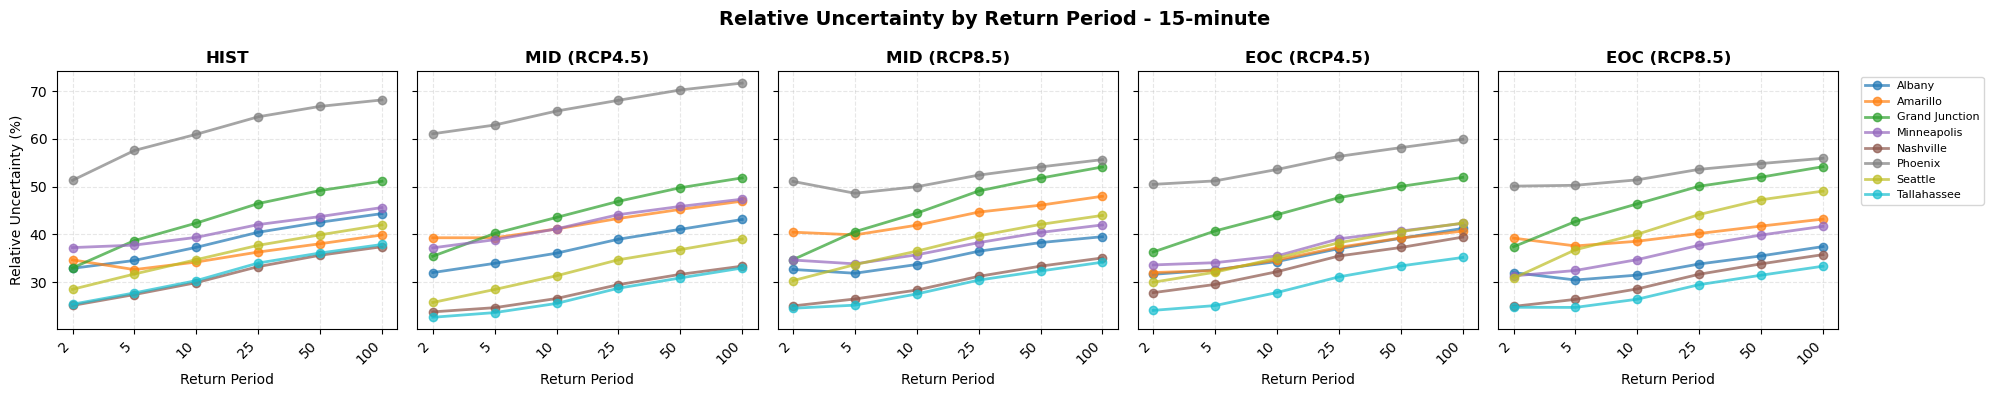

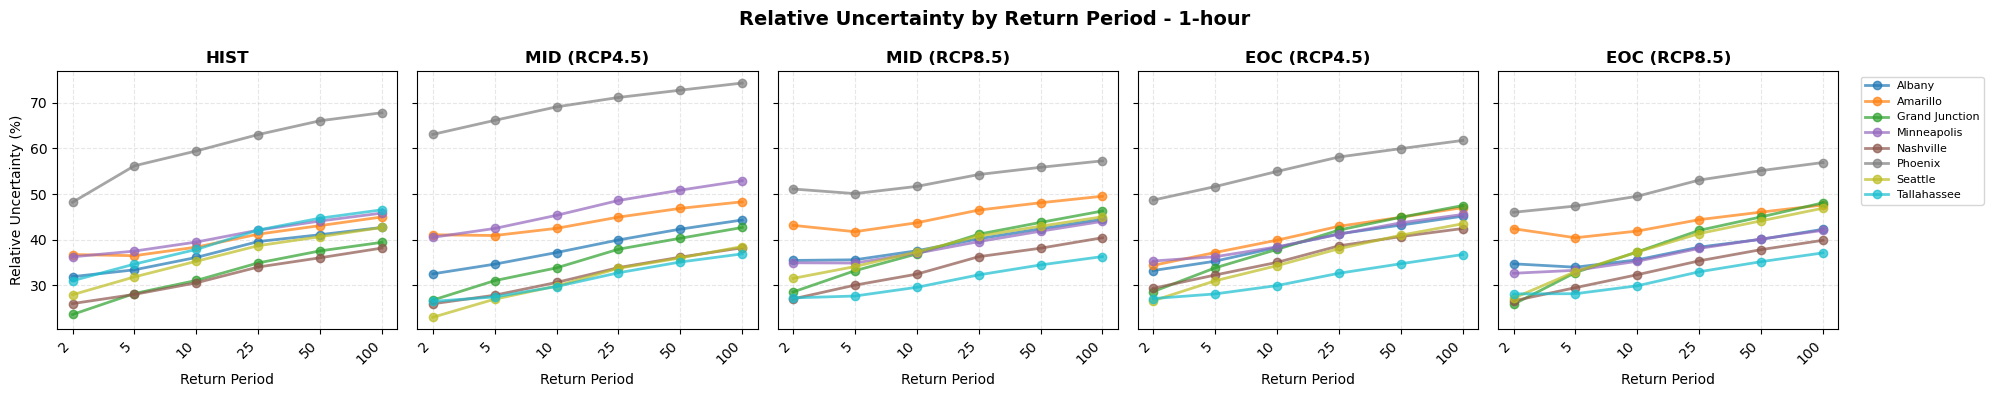

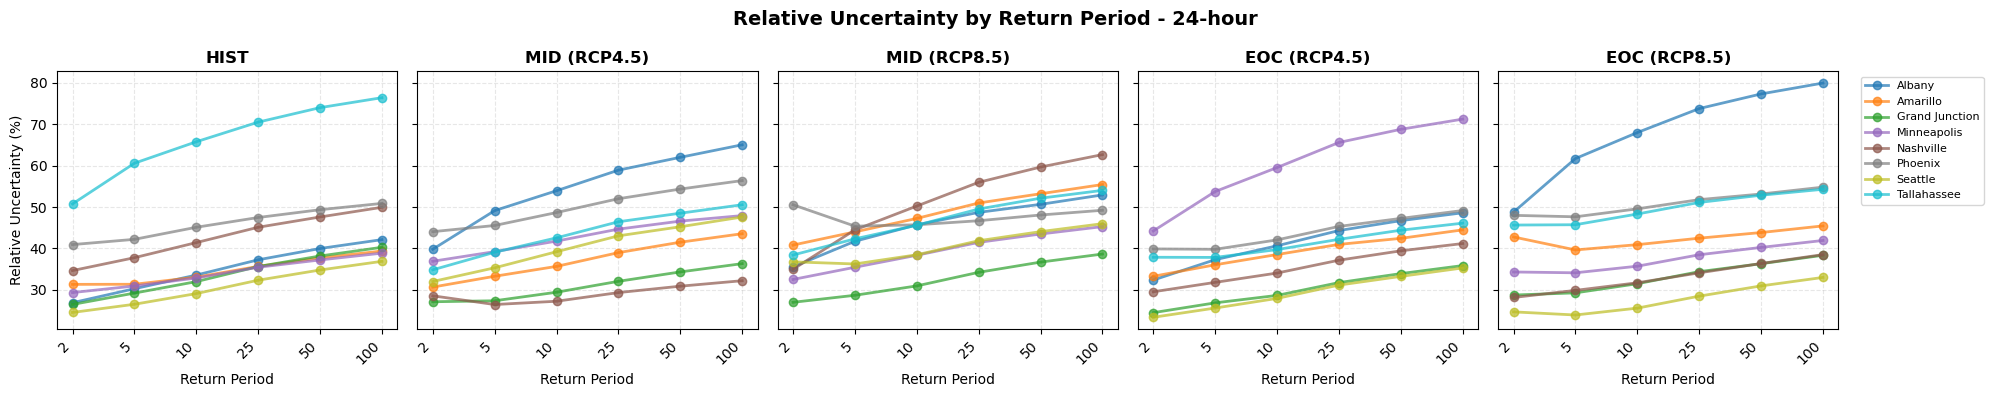

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_rel_unc_by_scenario_mpl(df, duration_name, duration_label):
    """
    Create plots showing relative uncertainty vs return period for each scenario.
    One subplot per scenario, colored by city. Pure matplotlib.
    """
    # Reshape data for plotting
    plot_data = {}
    
    for _, row in df.iterrows():
        city = row['City']
        scenario = row['Scenario']
        
        if scenario not in plot_data:
            plot_data[scenario] = {}
        
        if city not in plot_data[scenario]:
            plot_data[scenario][city] = {'rp': [], 'rel_unc': []}
        
        for rp in RETURN_PERIODS:
            rel_unc = row[f'{rp}yr_pct']
            if not np.isnan(rel_unc):
                plot_data[scenario][city]['rp'].append(rp)
                plot_data[scenario][city]['rel_unc'].append(rel_unc)
    
    # Set up color palette for cities
    cities_list = [city for city, _ in CITIES]
    colors = plt.cm.tab10(np.linspace(0, 1, len(cities_list)))
    city_colors = dict(zip(cities_list, colors))
    
    # Create figure with subplots (one per scenario)
    fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
    fig.suptitle(f'Relative Uncertainty by Return Period - {duration_label}', 
                 fontsize=14, fontweight='bold')
    
    # Plot each scenario
    for idx, (scenario_name, _, _) in enumerate(SCENARIOS):
        ax = axes[idx]
        
        # Plot each city
        for city in cities_list:
            if city in plot_data[scenario_name]:
                city_data = plot_data[scenario_name][city]
                
                # Sort by return period
                sorted_indices = np.argsort(city_data['rp'])
                rp_sorted = [city_data['rp'][i] for i in sorted_indices]
                unc_sorted = [city_data['rel_unc'][i] for i in sorted_indices]
                
                # Convert return periods to categorical positions
                rp_positions = [RETURN_PERIODS.index(rp) for rp in rp_sorted]
                
                ax.plot(rp_positions, 
                       unc_sorted,
                       marker='o', 
                       linewidth=2,
                       markersize=6,
                       color=city_colors[city],
                       label=city.split(',')[0],  # Just city name, no state
                       alpha=0.7)
        
        ax.set_title(scenario_name, fontsize=12, fontweight='bold')
        ax.set_xlabel('Return Period', fontsize=10)
        ax.set_xticks(range(len(RETURN_PERIODS)))
        ax.set_xticklabels([f'{rp}' for rp in RETURN_PERIODS], rotation=45, ha='right')
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Only show y-label on leftmost plot
        if idx == 0:
            ax.set_ylabel('Relative Uncertainty (%)', fontsize=10)
        
        # Only show legend on rightmost plot
        if idx == 4:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    return fig

# Generate plots for all durations
for duration_name in ['15min', '1hr', '24hr']:
    #print(f"\nGenerating plot for {duration_labels[duration_name]}...")
    
    fig = plot_rel_unc_by_scenario_mpl(
        idf_ci_tables[duration_name],
        duration_name,
        duration_labels[duration_name]
    )
    
    # Save figure
    output_file = os.path.join(OUTPUT_DIR, f"rel_unc_by_scenario_{duration_name}.png")
    fig.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()